# 01 Â· Exploratory analysis of the US Treasury yield curve

Daily constant-maturity Treasury yields from FRED (1M to 30Y), cleaned and cached by `yieldcurve.data`. This notebook looks at:

1. which maturities are available, and since when;
2. the shape of the curve on a few key dates;
3. the full history in one heatmap;
4. the 10Yâ€“2Y and 10Yâ€“3M spreads, inversion episodes, and how they line up with recessions.

The figures come from `yieldcurve.plots`, so the dashboard can reuse them. The data loads from `data/us_treasury_yields.parquet`; if that cache is missing it is built from FRED on the first run (`python -m yieldcurve.data` refreshes it).

In [1]:
import pandas as pd
import plotly.io as pio

from yieldcurve import plots, spreads
from yieldcurve.data import curve_on, load_us_yields

# Interactive figures in Jupyter / VS Code, plus a static PNG copy so the
# notebook still shows its charts on GitHub.
pio.renderers.default = "plotly_mimetype+png"
pio.renderers["png"].width = 900
pio.renderers["png"].height = 540

In [2]:
yields = load_us_yields()
yields.tail()

,1M,3M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
date,,,,,,,,,,,
2026-09-18,3.97,4.14,4.24,4.44,4.76,4.83,4.86,4.93,5.01,5.38,5.34
2026-09-21,3.96,4.17,4.27,4.45,4.76,4.82,4.83,4.89,4.96,5.33,5.29
2026-09-22,3.97,4.16,4.26,4.43,4.71,4.81,4.83,4.89,4.96,5.33,5.29
2026-09-23,3.99,4.19,4.31,4.49,4.85,4.97,4.99,5.05,5.11,5.45,5.40
2026-09-24,4.01,4.24,4.34,4.51,4.87,4.99,5.03,5.10,5.18,5.53,5.47


## Data coverage

Not every maturity exists over the whole history, so the first valid date per column matters for anything that needs the full curve.

In [3]:
coverage = pd.DataFrame(
    {
        "first_date": yields.apply(lambda s: s.first_valid_index().date()),
        "last_date": yields.apply(lambda s: s.last_valid_index().date()),
        "observations": yields.count(),
    }
)
coverage

,first_date,last_date,observations
1M,2001-07-31,2026-09-24,6290
3M,1981-09-01,2026-09-24,11267
6M,1981-09-01,2026-09-24,11267
1Y,1962-01-02,2026-09-24,16168
2Y,1976-06-01,2026-09-24,12576
3Y,1962-01-02,2026-09-24,16168
5Y,1962-01-02,2026-09-24,16168
7Y,1969-07-01,2026-09-24,14298
10Y,1962-01-02,2026-09-24,16168
20Y,1962-01-02,2026-09-24,14479


- The 1Y, 3Y, 5Y, 10Y and 20Y series start in 1962. The 30Y starts in 1977, and the 3M and 6M in September 1981.
- The 1M only starts on **2001-07-31**, so the full 11-point curve is available from then on. Later phases (Nelson-Siegel, PCA) work on that window.
- The 20Y has a structural gap in 1987â€“1993, when it was not issued. The pipeline leaves it missing instead of filling it.

## The curve on key dates

Four regimes, plus the latest curve for reference. Two of the dates are found from the data rather than typed in:

- **COVID low:** the day the 10Y hit its 2020 minimum.
- **2022 hiking peak:** the day the 2Y reached its 2022 high, i.e. when the market priced the most tightening that year.

Dates that fall on a weekend or holiday roll back to the previous trading day; the legend shows the date actually used.

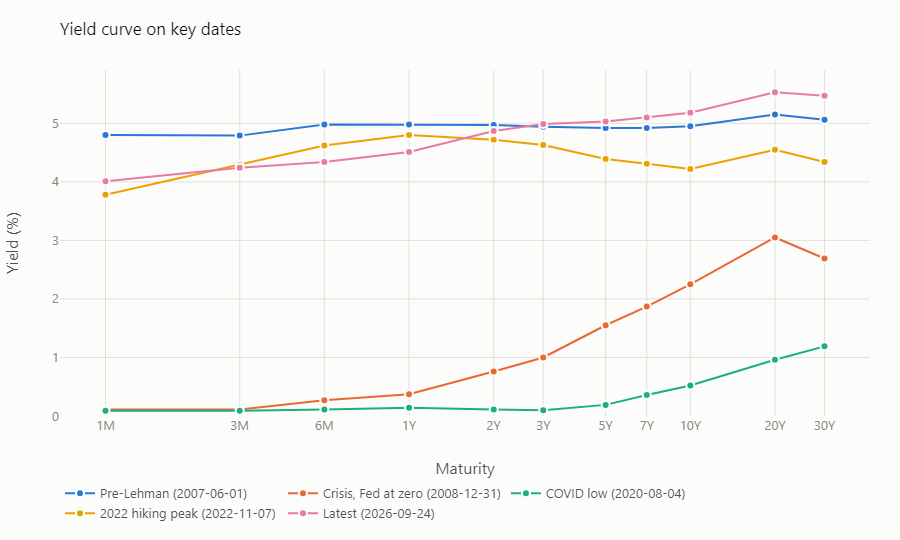

In [4]:
covid_low = yields.loc["2020", "10Y"].idxmin()
hiking_peak = yields.loc["2022", "2Y"].idxmax()

KEY_DATES = {
    "Pre-Lehman": "2007-06-01",
    "Crisis, Fed at zero": "2008-12-31",
    "COVID low": covid_low,
    "2022 hiking peak": hiking_peak,
    "Latest": yields.index[-1],
}
plots.curve_snapshots(yields, KEY_DATES)

In [5]:
curves = {label: curve_on(yields, date) for label, date in KEY_DATES.items()}
snapshots = pd.DataFrame(curves).T.reindex(columns=yields.columns).round(2)
snapshots.insert(0, "date", [curve.name.date() for curve in curves.values()])
snapshots

,date,1M,3M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
Pre-Lehman,2007-06-01,4.80,4.79,4.98,4.98,4.97,4.94,4.92,4.92,4.95,5.15,5.06
"Crisis, Fed at zero",2008-12-31,0.11,0.11,0.27,0.37,0.76,1.00,1.55,1.87,2.25,3.05,2.69
COVID low,2020-08-04,0.09,0.09,0.11,0.14,0.11,0.10,0.19,0.36,0.52,0.96,1.19
2022 hiking peak,2022-11-07,3.78,4.29,4.62,4.80,4.72,4.63,4.39,4.31,4.22,4.55,4.34
Latest,2026-09-24,4.01,4.24,4.34,4.51,4.87,4.99,5.03,5.10,5.18,5.53,5.47


What the shapes say:

- **Pre-Lehman (June 2007): flat.** Every maturity sat between 4.8% and 5.2%. The 10Y was only 16 bp above the 3M bill, which leaves little term premium just before the crisis.
- **End of 2008: steep.** The Fed cut to 0â€“0.25% on 16 December 2008. Bills yielded about 0.1% while the 10Y stayed at 2.25%. This is the classic easing-cycle shape: the front end is pinned by policy, and the long end prices an eventual recovery.
- **COVID low (2020-08-04): the whole curve near zero.** The 10Y closed at a record 0.52%, and only the 20Y and 30Y were anywhere near 1%.
- **2022 hiking peak (2022-11-07): inverted.** The curve peaks at the 1Y (4.80%), and the 10Y is 58 bp lower (4.22%). The market expected rates to be cut again after the hiking cycle.
- **Latest (cache through 2026-09-24): upward sloping again**, from 4.0% at the 1M to about 5.5% at the 20Y and 30Y.

One recurring detail: **the 20Y often yields more than the 30Y**, which bends the long end of the curve. A smooth curve model cannot produce that kink, so it is worth checking as a persistent residual in the Nelson-Siegel fits (Phase 3).

## Full history

Monthly averages of every maturity since 1962. Darker means higher yields; blank cells are maturities that were not issued at the time.

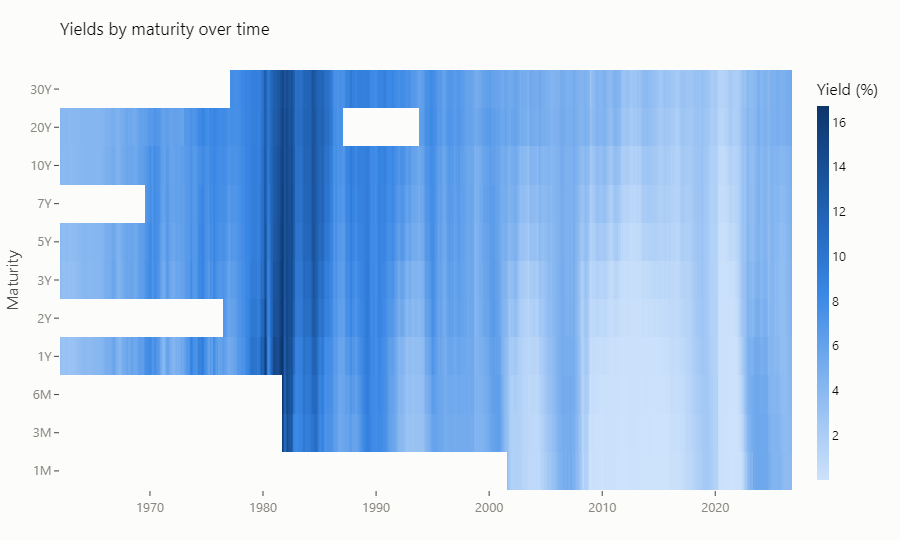

In [6]:
plots.yield_heatmap(yields)

- **The Volcker peak.** Short rates topped 17% in September 1981 (3M 17.01% on 1981-09-01, 1Y 17.31% on 1981-09-03), and the 10Y peaked at 15.84% on 1981-09-30.
- **Four decades of decline.** Yields at every maturity fell, with cycles along the way, from 1981 to 2020.
- **Two zero-rate periods.** The 3M bill stayed below 0.25% almost continuously from late 2008 to December 2015, and again from April 2020 to February 2022. These are the pale bands at the short end. The long end stayed higher, so the curve was steep in both periods.
- **The 2022 re-pricing.** The monthly average 3M rose from 0.15% in January 2022 to 4.36% in December. The front end overtook the long end within the year, which is the inversion seen in the snapshot above.

## Spreads and inversions

The term spread is the long yield minus the short yield, in percentage points; negative means the curve is **inverted**. Two spreads are standard:

- **10Yâ€“2Y**, the most quoted market measure (data from 1976);
- **10Yâ€“3M**, the one the New York Fed's recession model uses (data from 1981).

Gray bands are NBER recessions.

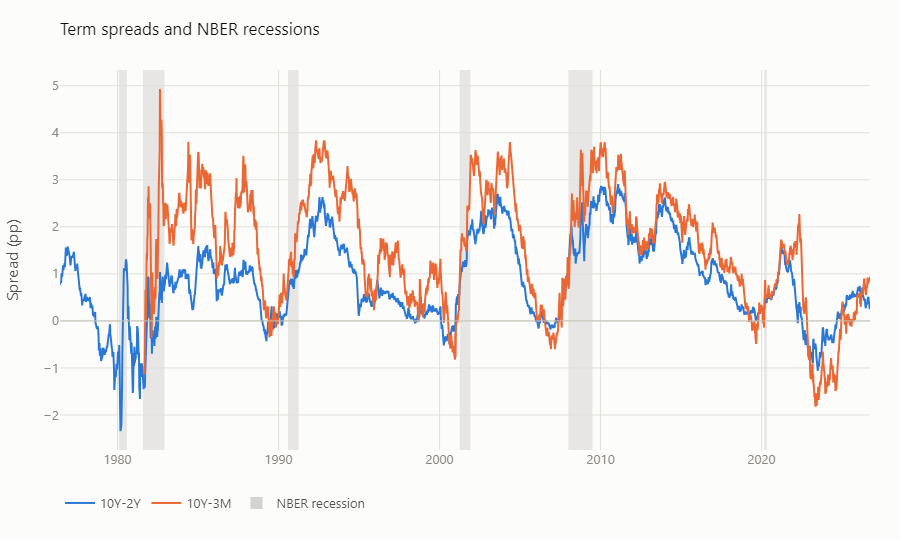

In [7]:
SPREADS = {
    "10Y-2Y": spreads.spread(yields, "10Y", "2Y"),
    "10Y-3M": spreads.spread(yields, "10Y", "3M"),
}
recessions = spreads.recession_periods()
# Weekly closes: daily detail is invisible over 50 years and bloats the notebook.
plots.spread_chart(
    SPREADS, recessions, title="Term spreads and NBER recessions", freq="W-FRI"
)

### Inversion episodes

Near zero the spreads flicker in and out of inversion: 10Yâ€“2Y has 44 raw negative runs and 10Yâ€“3M has 55. `find_inversions` counts an **episode** only if it lasts at least 10 trading days, and it bridges positive stretches of up to 5 days inside one. That leaves 12 and 13 episodes. The tables show the deepest point in basis points.

In [8]:
def episode_table(spread):
    episodes = spreads.find_inversions(spread)
    episodes["min_spread_bp"] = (episodes.pop("min_spread") * 100).round().astype(int)
    return episodes


EPISODES = {label: episode_table(s) for label, s in SPREADS.items()}
EPISODES["10Y-2Y"]

,start,end,trading_days,min_date,ongoing,min_spread_bp
0,1978-08-18,1980-05-01,423,1980-03-20,False,-241
1,1980-09-12,1981-11-05,286,1980-12-17,False,-170
2,1982-01-14,1982-07-16,127,1982-02-18,False,-71
3,1988-12-13,1989-06-29,137,1989-03-28,False,-45
4,1989-08-11,1989-10-11,42,1989-10-02,False,-20
5,1990-03-08,1990-03-29,16,1990-03-20,False,-14
6,1998-06-09,1998-07-09,22,1998-06-25,False,-7
7,2000-02-02,2000-12-28,229,2000-04-07,False,-52
8,2006-01-31,2006-03-07,25,2006-02-23,False,-16
9,2006-06-08,2007-03-20,196,2006-11-15,False,-19


In [9]:
EPISODES["10Y-3M"]

,start,end,trading_days,min_date,ongoing,min_spread_bp
0,1981-09-01,1981-09-22,15,1981-09-01,False,-160
1,1982-02-01,1982-02-18,12,1982-02-16,False,-96
2,1989-05-22,1989-08-25,68,1989-06-09,False,-35
3,1989-10-27,1989-12-28,43,1989-12-19,False,-15
4,2000-07-07,2001-01-19,135,2001-01-02,False,-95
5,2006-07-17,2007-05-29,219,2007-02-27,False,-64
6,2007-07-20,2007-08-09,15,2007-07-31,False,-18
7,2019-05-13,2019-10-10,106,2019-08-28,False,-52
8,2020-01-31,2020-03-02,21,2020-02-25,False,-20
9,2022-10-18,2024-12-12,539,2023-06-01,False,-189


### Lead time to recessions

For each recession, the table takes the **first** episode that started during the expansion before it (after the previous recession ended) and measures the months from that episode's start to the start of the recession. Episodes that start during a recession, like 1982, are not counted as signals. Blank cells mean no episode (or no data yet: the 10Yâ€“3M starts in September 1981).

In [10]:
def lead_times(episodes, recessions, data_start):
    starts = episodes["start"]
    rows = []
    previous_end = pd.Timestamp.min
    for rec in recessions.itertuples():
        window = starts[(starts > previous_end) & (starts < rec.start)]
        previous_end = rec.end
        if rec.start <= data_start:
            continue  # the spread was not observed before this recession
        first = window.min() if len(window) else pd.NaT
        rows.append(
            {
                "recession_start": rec.start.date(),
                "first_inversion": first.date() if pd.notna(first) else None,
                "lead_months": round((rec.start - first).days / 30.44, 1)
                if pd.notna(first)
                else None,
            }
        )
    return pd.DataFrame(rows).set_index("recession_start")


pd.concat(
    {
        label: lead_times(EPISODES[label], recessions, s.first_valid_index())
        for label, s in SPREADS.items()
    },
    axis=1,
)

10Y-2Y                      10Y-3M            
                first_inversion lead_months first_inversion lead_months
recession_start                                                        
1980-02-01           1978-08-18        17.5             NaN         NaN
1981-08-01           1980-09-12        10.6             NaN         NaN
1990-08-01           1988-12-13        19.6      1989-05-22        14.3
2001-04-01           1998-06-09        33.7      2000-07-07         8.8
2008-01-01           2006-01-31        23.0      2006-07-17        17.5
2020-03-01                 None         NaN      2019-05-13         9.6

What the spreads show:

- **Inversions came before recessions, by a long and variable lead.** Every recession since 1980 was preceded by at least one of the two spreads inverting. Leads range from about 9 to 34 months, so the signal says *whether*, not *when*.
- **2020 is the edge case.** The 10Yâ€“3M inverted from May to October 2019, about 10 months before the COVID recession. The 10Yâ€“2Y inverted for only 3 days (August 2019) and does not count as an episode under the 10-day rule. The recession itself came from an outside shock, so it is weak evidence either way.
- **2022â€“24 is the longest inversion in the sample.** The 10Yâ€“2Y inverted on **2022-07-06** and stayed inverted, with no break, until **2024-08-26** (537 trading days). Short dips below zero on 2024-09-03 and 2024-09-05 extend the episode to **2024-09-05**, 544 trading days. Its deepest point was âˆ’108 bp on 2023-07-03, the most inverted since the early 1980s. The 10Yâ€“3M inverted from 2022-10-18 to 2024-12-12 and went deeper (âˆ’189 bp on 2023-06-01). It dipped back below zero several times in 2025.
- **No recession has followed it so far.** NBER has dated no recession after 2020, through its latest data (August 2026). Either the lag is unusually long this time, or this is the first long, deep inversion in the sample without a recession. A common explanation is that the 2022 inflation shock pushed short rates up much faster than growth expectations fell.
- **Small sample.** There are six recessions here, so the curve is a useful warning light rather than a calibrated forecast. Phase 5's out-of-sample tests are the place to treat this formally.